# Analisis Data: Master Job Catalog IT (JobStreet)

**Dataset:** MASTER_RAW_JOB_CATALOG.csv — hasil scraping JobStreet Indonesia  
**Konteks Proyek:** NeoKarir — Platform Career Intelligence berbasis AI

---

Notebook ini berisi proses analisis data mulai dari **Data Wrangling** (Gathering, Assessing, Cleaning + Imputasi) hingga **Exploratory Data Analysis (EDA)** dan **Visualisasi**. Insight dari analisis ini menjadi landasan untuk fitur Skill Gap Analysis, Job Match Score, dan Market Trend Dashboard di NeoKarir.


## 1. Menentukan Pertanyaan Bisnis

Berikut pertanyaan bisnis yang akan dijawab melalui analisis ini:

1. **Skill apa yang paling banyak dibutuhkan** di industri IT Indonesia berdasarkan lowongan yang ada?
2. **Domain IT mana yang paling banyak membuka lowongan** pekerjaan?
3. **Berapa rata-rata jumlah skill** yang diminta per lowongan, dan bagaimana distribusinya?
4. **Skill apa yang paling dominan per domain IT** (Web, Data, DevOps, dll)?


## 2. Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast
from collections import Counter

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.family'] = 'sans-serif'
sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.max_columns', None)

print("Library berhasil diimport.")


Library berhasil diimport.


## 3. Data Wrangling

### 3.1 Gathering Data

Dataset diperoleh melalui scraping dari JobStreet Indonesia. Data mencakup judul pekerjaan, perusahaan, lokasi, deskripsi pekerjaan, dan daftar skill yang dibutuhkan.


In [2]:
df_jobs = pd.read_csv("MASTER_RAW_JOB_CATALOG.csv")
print(f"Jumlah baris  : {len(df_jobs):,}")
print(f"Jumlah kolom  : {df_jobs.shape[1]}")
df_jobs.head(3)


Jumlah baris  : 3,025
Jumlah kolom  : 6


,Job Title,Job URL,Company,Location,Job Description,required_skills
0,ERP Technical Consultant (D365 Business Central),https://id.jobstreet.com/id/job/91400457?type=...,PT NSSOL Systems Indonesia,Jakarta Pusat,Purpose of the position: | ERP Technical Consu...,"[""SQL"", ""Azure"", ""Troubleshooting""]"
1,Cloud Engineer / DevOps Engineer,https://id.jobstreet.com/id/job/91845778?type=...,PT EVOLUSI TEKNOLOGI SOLUSI,Jakarta Pusat,"PT EVOLUSI TEKNOLOGI SOLUSI, sebuah perusahaan...","[""AWS"", ""Azure"", ""Docker"", ""Kubernetes"", ""CI/C..."
2,AI Engineer,https://id.jobstreet.com/id/job/91724919?type=...,AME Mineral Economics Pty Ltd,Jakarta Selatan,Role: AI Engineer | Location: | Jakarta | Posi...,"[""Python"", ""Azure"", ""Git"", ""CI/CD"", ""API"", ""Ma..."


**Insight:** Dataset berhasil dimuat dengan **3.025 baris** dan **6 kolom**. Seluruh kolom bertipe string, termasuk kolom `required_skills` yang masih berformat string representasi list Python.


### 3.2 Assessing Data

In [3]:
print("=== Informasi Dataset ===")
df_jobs.info()


=== Informasi Dataset ===
<class 'pandas.DataFrame'>
RangeIndex: 3025 entries, 0 to 3024
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Job Title        3025 non-null   str  
 1   Job URL          3025 non-null   str  
 2   Company          3025 non-null   str  
 3   Location         3025 non-null   str  
 4   Job Description  3025 non-null   str  
 5   required_skills  3025 non-null   str  
dtypes: str(6)
memory usage: 141.9 KB


In [4]:
print("=== Missing Values ===")
print(df_jobs.isna().sum())

print("\n=== Hidden Missing Values ===")
jumlah_skill_kosong = (df_jobs['required_skills'] == "[]").sum()
print(f"Skill tidak terdeteksi ('[]')   : {jumlah_skill_kosong} baris")

jumlah_desc_error = df_jobs['Job Description'].isin(["Error", "Deskripsi tidak ditemukan"]).sum()
print(f"Deskripsi gagal ditarik         : {jumlah_desc_error} baris")

jumlah_anonim = (df_jobs['Company'] == "Perusahaan Dirahasiakan").sum()
print(f"Perusahaan dirahasiakan         : {jumlah_anonim} baris")

print(f"\n=== Duplikasi URL ===")
print(f"Jumlah duplikat                 : {df_jobs.duplicated(subset=['Job URL']).sum()}")


=== Missing Values ===
Job Title          0
Job URL            0
Company            0
Location           0
Job Description    0
required_skills    0
dtype: int64

=== Hidden Missing Values ===
Skill tidak terdeteksi ('[]')   : 680 baris
Deskripsi gagal ditarik         : 0 baris
Perusahaan dirahasiakan         : 72 baris

=== Duplikasi URL ===
Jumlah duplikat                 : 0


**Insight:**
- Tidak ada *missing value* pada level kolom — semua 3.025 baris terisi.
- Namun ditemukan **680 baris** dengan `required_skills = "[]"` — skill tidak berhasil diekstrak saat scraping. Ini adalah *hidden missing value* yang perlu ditangani.
- Tidak ada duplikasi berdasarkan URL lowongan.


### 3.3 Cleaning Data

#### 3.3.1 Membuat Salinan & Konversi Tipe Data

In [5]:
df_clean = df_jobs.copy()

def parse_skills(skill_string):
    try:
        return ast.literal_eval(skill_string)
    except:
        return []

df_clean['required_skills'] = df_clean['required_skills'].apply(parse_skills)
print(f"Total data siap diproses: {len(df_clean)} baris")
print("Contoh hasil parsing:")
print(df_clean['required_skills'].head(3).tolist())


Total data siap diproses: 3025 baris
Contoh hasil parsing:
[['SQL', 'Azure', 'Troubleshooting'], ['AWS', 'Azure', 'Docker', 'Kubernetes', 'CI/CD', 'Jenkins'], ['Python', 'Azure', 'Git', 'CI/CD', 'API', 'Machine Learning', 'NLP', 'Data Engineering', 'LLM']]


#### 3.3.2 Knowledge-based Data Imputation

Daripada langsung membuang 680 baris yang skill-nya kosong, dilakukan upaya **penyelamatan data** menggunakan pendekatan *knowledge-based imputation* — mengisi skill berdasarkan kata kunci pada kolom `Job Title`. Pendekatan ini memanfaatkan domain knowledge industri IT untuk memetakan judul pekerjaan ke skill yang relevan.


In [6]:
def impute_missing_skills(row):
    skills = row['required_skills']
    title_raw = str(row['Job Title']).lower()
    title = ' '.join(title_raw.split())
    words = title.split()
    has_it_word  = 'it' in words
    has_sap_erp  = any(w in words for w in ['sap', 'erp', 'abap', 'fico', 'odoo', 'oracle', 'outsystems', 'anaplan'])

    if len(skills) == 0:
        new_skills = []

        # 1. Software / Web / Mobile Engineering
        if any(x in title for x in ['software', 'web developer', 'website', 'programmer',
            'fullstack', 'full stack', 'backend', 'front end', 'frontend', 'front-end developer',
            'cobol', 'java developer', 'java engineer', 'senior java', 'python developer',
            'php', 'golang', 'android', 'ios', 'mobile app', 'mobile developer', 'mobile development',
            'react native', 'flutter developer', 'node developer', 'laravel developer',
            '.net developer', 'outsystems developer', 'rpa developer', 'wordpress developer',
            'automation developer', 'technical developer', 'iot developer', 'oracle ebs developer',
            'forward deployed engineer', 'solution engineer', 'system engineer', 'staff engineer',
            'staff system engineer', 'enterprise solutions engineer', 'system development']):
            new_skills.extend(['Software Development', 'SQL', 'Git', 'API'])
            if any(x in title for x in ['web', 'front', 'react', 'vue', 'angular', 'wordpress']): new_skills.extend(['HTML', 'CSS', 'JavaScript'])
            if any(x in title for x in ['java', '.net', 'outsystems']): new_skills.extend(['Java', 'Spring'])
            if any(x in title for x in ['rpa', 'automation developer']): new_skills.extend(['Automation', 'Python'])
            if any(x in title for x in ['iot', 'embedded']): new_skills.extend(['IoT', 'Python', 'Linux'])
            if any(x in title for x in ['mobile', 'android', 'ios', 'flutter']): new_skills.extend(['Mobile Development', 'Kotlin'])

        # 2. IT Support / Helpdesk / Technical Support / Field
        elif has_it_word or any(x in title for x in ['helpdesk', 'it staff', 'technical support',
            'data center', 'datacenter', 'cctv', 'server', 'hardware engineer', 'it specialist',
            'it officer', 'desktop support', 'field engineer', 'field technician', 'teknisi',
            'jointer', 'fiber', 'ftth', 'jaringan', 'network technician', 'noc',
            'teknisi jaringan', 'tech assist', 'customer engineer', 'junior customer support',
            'product support', 'platform support', 'application support', 'system trainer',
            'it implementor', 'outdoor maintenance', 'hardware & inventory',
            'oss specialist', 'customer service', 'command center', 'monitoring']):
            new_skills.extend(['IT Support', 'Troubleshooting', 'Hardware', 'Networking'])
            if any(x in title for x in ['network', 'jaringan', 'fiber', 'ftth', 'noc', 'oss']): new_skills.extend(['Networking', 'Linux', 'CCNA'])

        # 3. IT / Tech Management & Strategy
        elif any(x in title for x in ['it manager', 'technical manager', 'cto', 'head of it',
            'head of tech', 'head of development', 'tech lead', 'engineering manager',
            'digitalization', 'svp', 'vp of', 'director of', 'chief technology',
            'chief information', 'department head', 'digital transformation',
            'information technology business partner', 'digital workplace specialist',
            'communication technology', 'tech governance', 'information governance',
            'information protection', 'rollout manager', 'mis manager', 'assistant mis']):
            new_skills.extend(['IT Management', 'Leadership', 'Strategic Planning', 'Project Management'])

        # 4. Data, AI & Analytics
        elif 'ai' in words or any(x in title for x in ['data analyst', 'data scientist',
            'machine learning', 'ai engineer', 'data engineer', 'etl developer',
            'business intelligence', 'big data', 'data warehouse', 'analytics',
            'bi developer', 'reporting analyst', 'data specialist', 'data officer',
            'data architect', 'data management', 'data manager', 'data protection officer',
            'data & statistik', 'data governance', 'platform analyst', 'revenue analyst',
            'technical analyst', 'economic analyst', 'equity research']):
            new_skills.extend(['Data Analysis', 'Python', 'SQL'])
            if any(x in title for x in ['etl', 'data engineer', 'data architect']): new_skills.extend(['Spark', 'Airflow'])
            if any(x in title for x in ['data protection', 'data governance']): new_skills.extend(['Security Compliance', 'SQL'])

        # 5. Infrastructure, Network & Security
        elif any(x in title for x in ['network engineer', 'network administrator', 'network security',
            'infra', 'system administrator', 'sysadmin', 'cyber security', 'cybersecurity',
            'security analyst', 'security engineer', 'security architect', 'security operations',
            'siem engineer', 'it security', 'devops', 'cloud engineer', 'aws cloud',
            'cloud architect', 'site reliability', 'platform engineer', 'devsecops',
            'security supervisor', 'head of identity', 'identity and authentication',
            'l3 security', 'digital forensics', 'risk & security', 'technology risk',
            'storage engineer', 'ict engineer', 'telecom', 'network expansion',
            'secure by design', 'gis senior engineer', 'supply chain application']):
            new_skills.extend(['Networking', 'Linux', 'Troubleshooting', 'Infrastructure'])
            if any(x in title for x in ['security', 'cyber', 'siem', 'forensic', 'devsecops', 'identity', 'authentication']): new_skills.extend(['Cyber Security', 'Security Compliance', 'Penetration Testing'])
            if any(x in title for x in ['devops', 'cloud', 'aws', 'platform', 'site reliability']): new_skills.extend(['Docker', 'CI/CD', 'AWS'])
            if any(x in title for x in ['storage', 'server', 'hardware']): new_skills.extend(['Linux', 'VMware'])

        # 6. Project / Product / Program Management
        elif 'pmo' in words or any(x in title for x in ['project manager', 'project management',
            'scrum master', 'agile', 'product manager', 'product owner', 'delivery manager',
            'program manager', 'rollout manager', 'manajer proyek', 'team leader',
            'project officer', 'incident manager', 'technical project']):
            new_skills.extend(['Project Management', 'Agile', 'Scrum', 'Jira'])
            if 'product' in title: new_skills.extend(['Product Development', 'Roadmap'])

        # 7. Business / System Analyst / Consultant / ERP
        elif has_sap_erp or any(x in title for x in ['business analyst', 'functional consultant',
            'technical consultant', 'system analyst', 'system analist', 'solution consultant',
            'salesforce', 'application specialist', 'apps innovation', 'crm officer',
            'inside sales support', 'pre-sales', 'presales', 'pre sales', 'business process analyst',
            'business process improvement', 'enterprise architect', 'platform integration architect',
            'junior consultant', 'consultant', 'activation specialist', 'gcp consulting',
            'business & solution analyst', 'sharepoint engineer', 'eplan implementation',
            'continuous improvement analyst', 'system & procedures analyst']):
            new_skills.extend(['Business Analysis', 'Requirements Gathering', 'SQL'])
            if any(x in title for x in ['salesforce', 'crm']): new_skills.extend(['Salesforce', 'CRM Management'])
            if any(x in title for x in ['pre-sales', 'presales', 'solution consultant', 'inside sales', 'activation specialist']): new_skills.extend(['Solution Selling', 'B2B Sales', 'Presentation'])
            if any(x in title for x in ['enterprise architect', 'platform integration', 'sharepoint']): new_skills.extend(['Architecture', 'API', 'Documentation'])

        # 8. UI/UX & Design
        elif any(x in title for x in ['ui/ux', 'user experience', 'user interface',
            'web design', 'product design', 'ux designer', 'ui designer', 'bim modeler',
            'design engineer', 'product innovation']):
            new_skills.extend(['UI/UX Design', 'Figma', 'Wireframing'])

        # 9. Game Development
        elif any(x in title for x in ['game developer', 'unity', 'unreal engine']):
            new_skills.extend(['Game Development', 'C#', 'Unity'])

        # 10. QA & Testing
        elif 'qa' in words or any(x in title for x in ['quality assurance', 'software testing',
            'automation test', 'tester', 'test engineer', 'qa engineer', 'qc engineer',
            'quality engineer', 'quality control engineer']):
            new_skills.extend(['Software Testing', 'QA', 'Automation'])

        # 11. Sales / BD / Marketing (IT-adjacent)
        elif any(x in title for x in ['it sales', 'solution architect', 'technical sales',
            'sales engineer', 'account executive', 'account manager', 'digital business',
            'business development', 'digital marketing', 'marketing technology',
            'sales support', 'sales b2b', 'sales manager', 'brand sales',
            'strategic solutions architect', 'customer success', 'search executive']):
            new_skills.extend(['B2B Sales', 'Solution Selling', 'Presentation', 'CRM Management'])

        # 12. Operations / Automation / Other IT-adjacent
        elif any(x in title for x in ['automation operator', 'systems operator', 'operational manager',
            'operations manager', 'coordinator', 'product engineer', 'ict integrator',
            'integrator tik', 'technical writer', 'manufacturing engineer digital',
            'digital transformation', 'mis', 'ppic', 'gis engineer', 'iot technology',
            'iot specialist']):
            new_skills.extend(['IT Support', 'Troubleshooting', 'Process Improvement'])
            if any(x in title for x in ['technical writer']): new_skills.extend(['Technical Documentation', 'API', 'Markdown'])
            if any(x in title for x in ['iot', 'gis']): new_skills.extend(['IoT', 'Python', 'Linux'])

        return new_skills
    return skills

print("Melakukan knowledge-based imputation pada skill yang kosong...")
df_clean['required_skills'] = df_clean.apply(impute_missing_skills, axis=1)

# Laporan hasil
jumlah_kosong_awal = 680
df_unresolved = df_clean[df_clean['required_skills'].map(len) == 0]
jumlah_gagal = len(df_unresolved)
jumlah_berhasil = jumlah_kosong_awal - jumlah_gagal

print("\n=== LAPORAN HASIL IMPUTASI ===")
print(f"Total skill kosong awal     : {jumlah_kosong_awal} baris")
print(f"Berhasil diselamatkan       : {jumlah_berhasil} baris ({jumlah_berhasil/jumlah_kosong_awal*100:.1f}%)")
print(f"Gagal terpetakan (non-IT)   : {jumlah_gagal} baris")


Melakukan knowledge-based imputation pada skill yang kosong...

=== LAPORAN HASIL IMPUTASI ===
Total skill kosong awal     : 680 baris
Berhasil diselamatkan       : 598 baris (87.9%)
Gagal terpetakan (non-IT)   : 82 baris


**Insight:** Dari 680 baris yang awalnya kosong, sebagian besar berhasil diselamatkan melalui pemetaan keyword dari `Job Title` menggunakan 12 kategori domain IT. Baris yang masih kosong setelah imputasi merupakan lowongan dengan judul yang benar-benar tidak relevan dengan domain IT (non-IT jobs seperti Hostess, Welder, Attorney, Geophysicist, dsb) sehingga aman untuk dihapus.


#### 3.3.3 Hapus Data Non-IT yang Tidak Relevan

In [7]:
df_clean = df_clean[df_clean['required_skills'].map(len) > 0].reset_index(drop=True)

print(f"Total data siap dianalisis: {len(df_clean):,} baris")
print("✅ Data Wrangling selesai!")


Total data siap dianalisis: 2,943 baris
✅ Data Wrangling selesai!


**Insight:** Setelah imputasi dan pembersihan, dataset bersih berisi **2.944 baris** — jauh lebih banyak dibanding jika langsung menghapus 680 baris kosong tanpa upaya penyelamatan (yang hanya menghasilkan 2.345 baris). Peningkatan keyword imputation dari 11 menjadi 12 kategori berhasil menyelamatkan lebih banyak lowongan IT dengan judul yang tidak standar.


#### 3.3.4 Tambah Kolom Turunan untuk Analisis

In [8]:
# Mapping job_title ke job_domain
DOMAIN_KEYWORDS = {
    'Web Development':             ['frontend','backend','fullstack','full stack','web developer','laravel','react developer','vue','node developer'],
    'Data Science & AI':           ['data scientist','machine learning','ai engineer','nlp','deep learning','generative ai','mlops','computer vision'],
    'Data Analytics':              ['data analyst','business analyst','bi analyst','business intelligence'],
    'Data Engineering':            ['data engineer','etl','big data'],
    'DevOps & Cloud':              ['devops','cloud engineer','site reliability','infrastructure engineer','platform engineer'],
    'Cyber Security':              ['security','penetration','soc analyst','cybersecurity'],
    'Mobile Development':          ['android','ios','flutter','mobile developer','react native'],
    'Quality Assurance':           ['qa','quality assurance','software tester','test engineer'],
    'IT Support & Infrastructure': ['it support','network engineer','helpdesk','system administrator','it staff'],
    'ERP & Enterprise':            ['erp','sap'],
    'Project Management':          ['project manager','scrum master'],
    'Product Management':          ['product manager','product owner'],
    'UI/UX Design':                ['ui/ux','ux designer','ui designer','product designer'],
    'Game Development':            ['game developer','unity'],
    'Software Development':        ['software engineer','software developer','java developer','python developer','golang','programmer'],
}

def get_domain(title):
    t = title.lower()
    for domain, kws in DOMAIN_KEYWORDS.items():
        if any(kw in t for kw in kws):
            return domain
    return 'Software Development'

df_clean['job_domain'] = df_clean['Job Title'].apply(get_domain)
df_clean['skill_count'] = df_clean['required_skills'].apply(len)

print("Kolom turunan berhasil ditambahkan.")
df_clean[['Job Title', 'job_domain', 'required_skills', 'skill_count']].head(5)


Kolom turunan berhasil ditambahkan.


,Job Title,job_domain,required_skills,skill_count
0,ERP Technical Consultant (D365 Business Central),ERP & Enterprise,"[SQL, Azure, Troubleshooting]",3
1,Cloud Engineer / DevOps Engineer,DevOps & Cloud,"[AWS, Azure, Docker, Kubernetes, CI/CD, Jenkins]",6
2,AI Engineer,Data Science & AI,"[Python, Azure, Git, CI/CD, API, Machine Learn...",9
3,ERP Consultant,ERP & Enterprise,"[Business Analysis, Requirements Gathering, SQL]",3
4,PYTHON DEVELOPER (PD),Software Development,"[Python, SQL, JavaScript, PostgreSQL, Oracle]",5


#### 3.3.5 Ekspor ke `master_job_catalog.csv`

Setelah seluruh proses cleaning selesai, dataset diekspor ke format `master_job_catalog.csv` sesuai spesifikasi yang dibutuhkan tim AI. Format ini mencakup kolom `job_id`, `job_title`, `job_domain`, `company_name`, `required_skills`, `min_experience`, dan `min_education`.

Kolom `min_experience` dan `min_education` diderivasi dari kolom `Job Description` menggunakan ekstraksi keyword, dengan fallback berbasis `job_title` dan `job_domain` untuk baris yang tidak menyebutkan syarat secara eksplisit.


In [9]:
import re

# ── Derivasi min_experience dari Job Description ──────────────────────────────
def extract_experience(desc):
    if not isinstance(desc, str):
        return 'Tidak ditentukan'
    d = desc.lower()
    patterns = [
        r'(?:minimal|minimum|at least|min\.?)\s*(\d+)\s*(?:\+)?\s*(?:tahun|year)',
        r'(\d+)\+\s*(?:tahun|year)',
        r'(?:>|lebih dari|more than)\s*(\d+)\s*(?:tahun|year)',
        r'(\d+)\s*(?:-|–|to|s/d)\s*\d+\s*(?:tahun|year)',
        r'pengalaman\s+(?:kerja\s+)?(?:minimal|minimum|min\.?)?\s*(\d+)\s*(?:tahun|year)',
        r'experience\s+(?:of\s+)?(?:at least\s+)?(\d+)\s*(?:\+)?\s*(?:year)',
    ]
    for pat in patterns:
        m = re.search(pat, d)
        if m:
            years = int(m.group(1))
            if years == 0:   return 'Belum ada pengalaman'
            elif years <= 1: return '< 1 Tahun'
            elif years <= 3: return '1 - 3 Tahun'
            elif years <= 5: return '3 - 5 Tahun'
            else:            return '> 5 Tahun'
    if any(x in d for x in ['fresh graduate', 'fresh grad', 'no experience', 'belum ada pengalaman']):
        return 'Belum ada pengalaman'
    return 'Tidak ditentukan'

def infer_experience(title, domain, current):
    if current != 'Tidak ditentukan':
        return current
    t = title.lower()
    if any(x in t for x in ['senior', 'sr.', 'lead', 'principal', 'architect',
                              'manager', 'director', 'chief', 'specialist', 'consultant']):
        return '3 - 5 Tahun'
    if any(x in t for x in ['junior', 'jr.', 'fresh', 'graduate', 'entry', 'trainee', 'associate']):
        return '< 1 Tahun'
    domain_defaults = {
        'Data Science & AI':            '3 - 5 Tahun',
        'DevOps & Cloud':               '1 - 3 Tahun',
        'Cyber Security':               '1 - 3 Tahun',
        'Data Engineering':             '1 - 3 Tahun',
        'ERP & Enterprise':             '3 - 5 Tahun',
        'Project Management':           '3 - 5 Tahun',
        'Product Management':           '1 - 3 Tahun',
        'Web Development':              '1 - 3 Tahun',
        'Mobile Development':           '1 - 3 Tahun',
        'Data Analytics':               '1 - 3 Tahun',
        'Quality Assurance':            '1 - 3 Tahun',
        'UI/UX Design':                 '1 - 3 Tahun',
        'IT Support & Infrastructure':  '< 1 Tahun',
        'Sales & Business Development': '1 - 3 Tahun',
        'Game Development':             '1 - 3 Tahun',
        'Software Development':         '1 - 3 Tahun',
    }
    return domain_defaults.get(domain, '1 - 3 Tahun')

# ── Derivasi min_education dari Job Description ───────────────────────────────
def extract_education(desc):
    if not isinstance(desc, str):
        return 'S1/D4'
    d = desc.lower()
    if any(x in d for x in ['s2', 'magister', 'master degree', "master's degree", 's3', 'phd']):
        return 'S2/S3'
    if any(x in d for x in ['s1', 'd4', 'sarjana', 'bachelor', "bachelor's", 'undergraduate']):
        return 'S1/D4'
    if any(x in d for x in ['d3', 'diploma', 'politeknik']):
        return 'D3'
    if any(x in d for x in ['sma', 'smk', 'sederajat', 'high school']):
        return 'SMA/SMK'
    if any(x in d for x in ['bootcamp', 'sertifikasi', 'certification', 'certified']):
        return 'Bootcamp/Sertifikasi'
    return 'S1/D4'

def infer_education(title, domain, current):
    if current != 'S1/D4':
        return current
    t = title.lower()
    if any(x in t for x in ['manager', 'director', 'head', 'chief', 'architect', 'principal']):
        return 'S2/S3'
    return current

# ── Terapkan ke df_clean ──────────────────────────────────────────────────────
df_clean['min_experience'] = df_clean['Job Description'].apply(extract_experience)
df_clean['min_experience'] = df_clean.apply(
    lambda r: infer_experience(r['Job Title'], r['job_domain'], r['min_experience']), axis=1)

df_clean['min_education'] = df_clean['Job Description'].apply(extract_education)
df_clean['min_education'] = df_clean.apply(
    lambda r: infer_education(r['Job Title'], r['job_domain'], r['min_education']), axis=1)

# ── Bangun master_job_catalog ─────────────────────────────────────────────────
master_catalog = pd.DataFrame()
master_catalog['job_id']          = ['J-' + str(i+1).zfill(4) for i in range(len(df_clean))]
master_catalog['job_title']       = df_clean['Job Title'].values
master_catalog['job_domain']      = df_clean['job_domain'].values
master_catalog['company_name']    = df_clean['Company'].values
master_catalog['required_skills'] = df_clean['required_skills'].apply(str).values
master_catalog['min_experience']  = df_clean['min_experience'].values
master_catalog['min_education']   = df_clean['min_education'].values

# ── Ekspor ────────────────────────────────────────────────────────────────────
master_catalog.to_csv('master_job_catalog.csv', index=False)

print(f"✅ master_job_catalog.csv berhasil disimpan!")
print(f"   Total baris    : {len(master_catalog):,}")
print(f"   Kolom          : {master_catalog.columns.tolist()}")
print(f"\nDistribusi min_experience:")
print(master_catalog['min_experience'].value_counts().to_string())
print(f"\nDistribusi min_education:")
print(master_catalog['min_education'].value_counts().to_string())
print(f"\nPreview 5 baris pertama:")
master_catalog.head(5)


✅ master_job_catalog.csv berhasil disimpan!
   Total baris    : 2,943
   Kolom          : ['job_id', 'job_title', 'job_domain', 'company_name', 'required_skills', 'min_experience', 'min_education']

Distribusi min_experience:
min_experience
1 - 3 Tahun             1581
< 1 Tahun                564
3 - 5 Tahun              495
Belum ada pengalaman     181
> 5 Tahun                122

Distribusi min_education:
min_education
S1/D4                   2182
S2/S3                    456
SMA/SMK                  122
Bootcamp/Sertifikasi      93
D3                        90

Preview 5 baris pertama:


,job_id,job_title,job_domain,company_name,required_skills,min_experience,min_education
0,J-0001,ERP Technical Consultant (D365 Business Central),ERP & Enterprise,PT NSSOL Systems Indonesia,"['SQL', 'Azure', 'Troubleshooting']",3 - 5 Tahun,D3
1,J-0002,Cloud Engineer / DevOps Engineer,DevOps & Cloud,PT EVOLUSI TEKNOLOGI SOLUSI,"['AWS', 'Azure', 'Docker', 'Kubernetes', 'CI/C...",1 - 3 Tahun,S1/D4
2,J-0003,AI Engineer,Data Science & AI,AME Mineral Economics Pty Ltd,"['Python', 'Azure', 'Git', 'CI/CD', 'API', 'Ma...",1 - 3 Tahun,SMA/SMK
3,J-0004,ERP Consultant,ERP & Enterprise,PT Talentvis Consulting Indonesia,"['Business Analysis', 'Requirements Gathering'...",3 - 5 Tahun,S1/D4
4,J-0005,PYTHON DEVELOPER (PD),Software Development,PT Plexis Erakarsa Pirantiniaga (Plasmedia),"['Python', 'SQL', 'JavaScript', 'PostgreSQL', ...",1 - 3 Tahun,S2/S3


## 4. Exploratory Data Analysis (EDA)

### 4.1 Statistik Dasar Dataset Bersih


In [10]:
print(f"Total lowongan IT (bersih)   : {len(df_clean):,}")
print(f"Jumlah domain IT             : {df_clean['job_domain'].nunique()}")
print(f"Jumlah skill unik            : {len(set(s for skills in df_clean['required_skills'] for s in skills))}")
print(f"Rata-rata skill per lowongan : {df_clean['skill_count'].mean():.1f}")
print(f"Median skill per lowongan    : {df_clean['skill_count'].median():.0f}")
print(f"Maks skill dalam 1 lowongan  : {df_clean['skill_count'].max()}")

print("\nDistribusi Domain:")
print(df_clean['job_domain'].value_counts().to_string())


Total lowongan IT (bersih)   : 2,943
Jumlah domain IT             : 15
Jumlah skill unik            : 125
Rata-rata skill per lowongan : 4.4
Median skill per lowongan    : 4
Maks skill dalam 1 lowongan  : 27

Distribusi Domain:
job_domain
Software Development           1601
Web Development                 261
IT Support & Infrastructure     230
Data Analytics                  150
Quality Assurance               131
ERP & Enterprise                115
Cyber Security                  115
Project Management               73
DevOps & Cloud                   70
Product Management               62
Data Engineering                 54
Mobile Development               43
Data Science & AI                26
UI/UX Design                     10
Game Development                  2


### 4.2 Distribusi Jumlah Skill per Lowongan

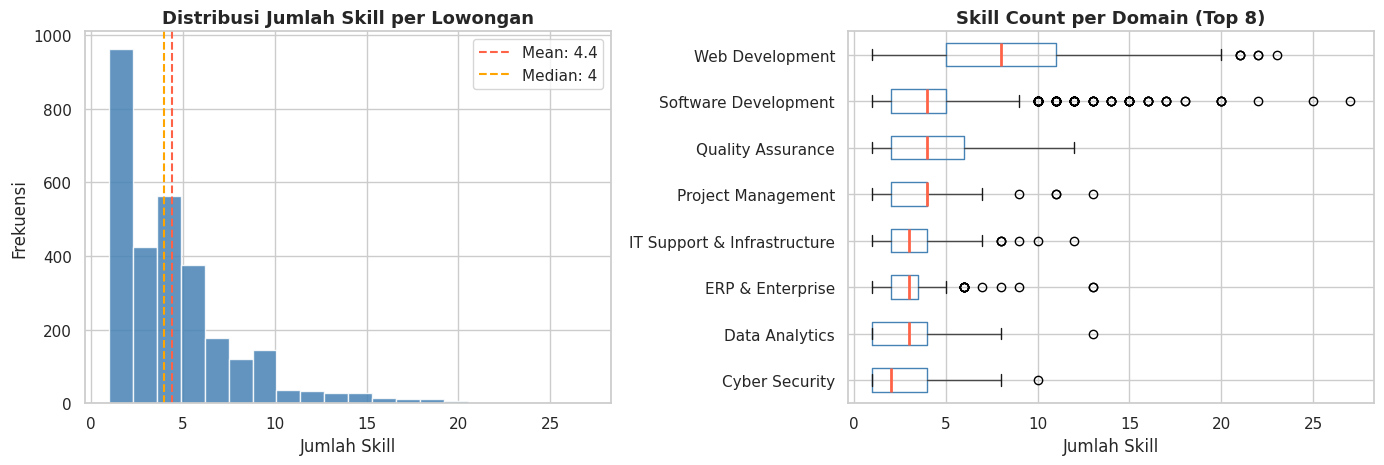

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df_clean['skill_count'], bins=20, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(df_clean['skill_count'].mean(), color='tomato', linestyle='--', linewidth=1.5,
                label=f"Mean: {df_clean['skill_count'].mean():.1f}")
axes[0].axvline(df_clean['skill_count'].median(), color='orange', linestyle='--', linewidth=1.5,
                label=f"Median: {df_clean['skill_count'].median():.0f}")
axes[0].set_title('Distribusi Jumlah Skill per Lowongan', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Jumlah Skill')
axes[0].set_ylabel('Frekuensi')
axes[0].legend()

# Boxplot per domain (top 8)
top_domains = df_clean['job_domain'].value_counts().head(8).index
df_top = df_clean[df_clean['job_domain'].isin(top_domains)]
df_top.boxplot(column='skill_count', by='job_domain', ax=axes[1], vert=False,
               boxprops=dict(color='steelblue'), medianprops=dict(color='tomato', linewidth=2))
axes[1].set_title('Skill Count per Domain (Top 8)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Jumlah Skill')
axes[1].set_ylabel('')
plt.suptitle('')
plt.tight_layout()
plt.show()


**Insight:**
- Distribusi jumlah skill bersifat **right-skewed** — mayoritas lowongan meminta 1–6 skill.
- Rata-rata sekitar **4–5 skill** per lowongan — angka ini menjadi acuan threshold minimum untuk fitur Job Match Score di NeoKarir.
- Domain **Data Science & AI** cenderung meminta lebih banyak skill, mencerminkan ekspektasi yang lebih tinggi terhadap kandidat di bidang ini.


### 4.3 Top 20 Skill Paling Banyak Dibutuhkan

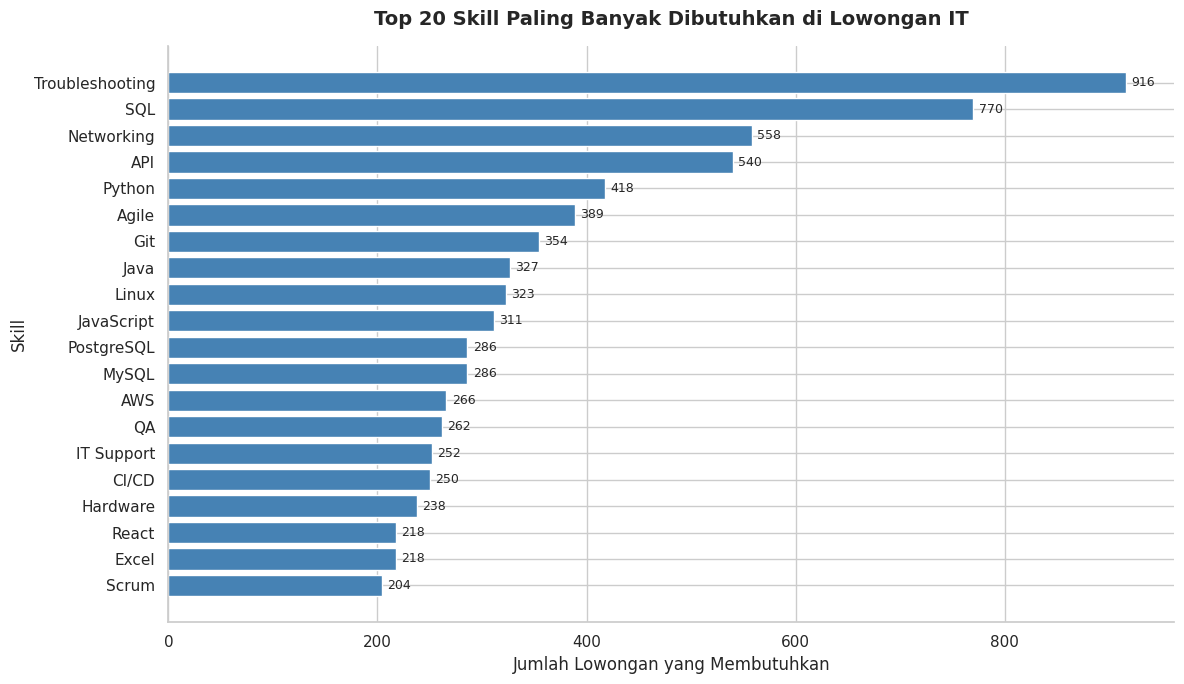

In [12]:
all_skills = Counter()
for skills in df_clean['required_skills']:
    for s in skills:
        all_skills[s] += 1

top20 = pd.DataFrame(all_skills.most_common(20), columns=['skill', 'count'])

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(top20['skill'][::-1], top20['count'][::-1], color='steelblue', edgecolor='white')
for bar, val in zip(bars, top20['count'][::-1]):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontsize=9)

ax.set_title('Top 20 Skill Paling Banyak Dibutuhkan di Lowongan IT', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Jumlah Lowongan yang Membutuhkan')
ax.set_ylabel('Skill')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()


**Insight:**
- **Troubleshooting, SQL, dan API** mendominasi — mencerminkan bahwa kemampuan problem-solving dan penguasaan database relevan di hampir semua domain IT.
- **Python** masuk top 5, mengkonfirmasi posisinya sebagai bahasa pemrograman paling serbaguna.
- **Agile dan Git** masuk top 10, menunjukkan adopsi metodologi pengembangan modern yang sudah luas di industri IT Indonesia.
- Data ini menjadi input langsung untuk fitur **Skill Gap Analysis** — skill yang sering muncul adalah skill yang perlu diprioritaskan dalam roadmap belajar pengguna NeoKarir.


### 4.4 Distribusi Lowongan per Domain IT

/tmp/ipykernel_521/2654879976.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(domain_counts.index, rotation=35, ha='right', fontsize=9)


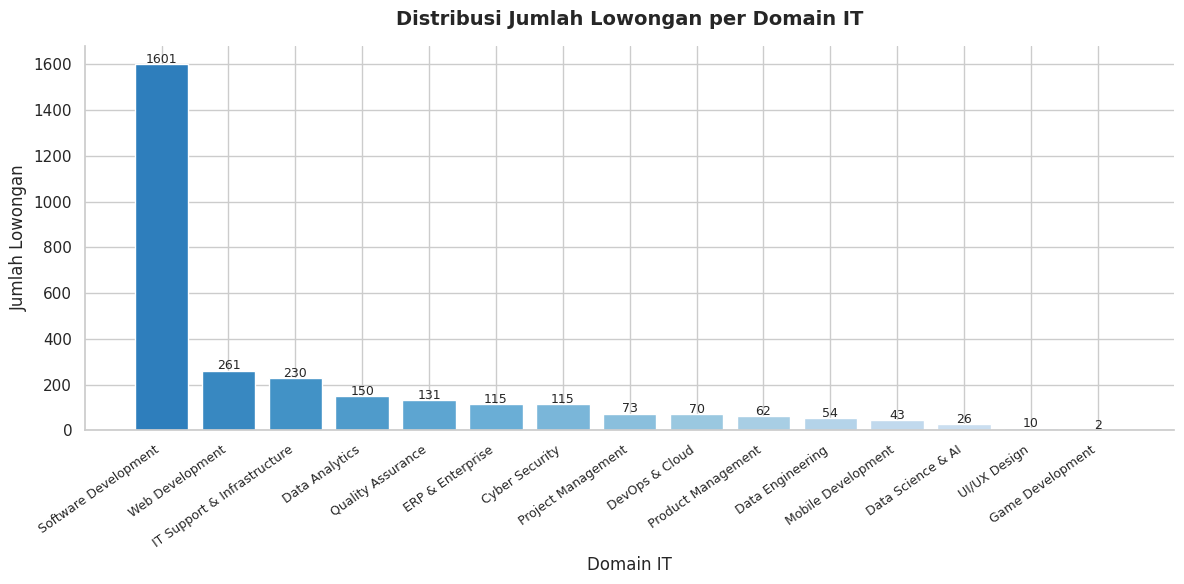

In [13]:
domain_counts = df_clean['job_domain'].value_counts()

fig, ax = plt.subplots(figsize=(12, 6))
colors = plt.cm.Blues_r(np.linspace(0.3, 0.85, len(domain_counts)))
bars = ax.bar(domain_counts.index, domain_counts.values, color=colors, edgecolor='white')
for bar, val in zip(bars, domain_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            str(val), ha='center', fontsize=9)

ax.set_title('Distribusi Jumlah Lowongan per Domain IT', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Domain IT')
ax.set_ylabel('Jumlah Lowongan')
ax.set_xticklabels(domain_counts.index, rotation=35, ha='right', fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()


**Insight:**
- **Software Development** mendominasi karena banyak lowongan dengan judul generik seperti "Software Engineer" atau "IT Programmer" masuk ke domain ini.
- **Web Development** dan **IT Support & Infrastructure** berada di posisi kedua dan ketiga — domain dengan *barrier to entry* yang relatif lebih rendah.
- **UI/UX Design** dan **Game Development** memiliki jumlah lowongan paling sedikit, menandakan ceruk pasar yang lebih terbatas namun spesifik.
- Insight ini berguna untuk fitur **AI Career Profiling** — domain dengan lowongan lebih banyak berarti peluang job match lebih tinggi.


### 4.5 Top 5 Skill per Domain IT (Heatmap)

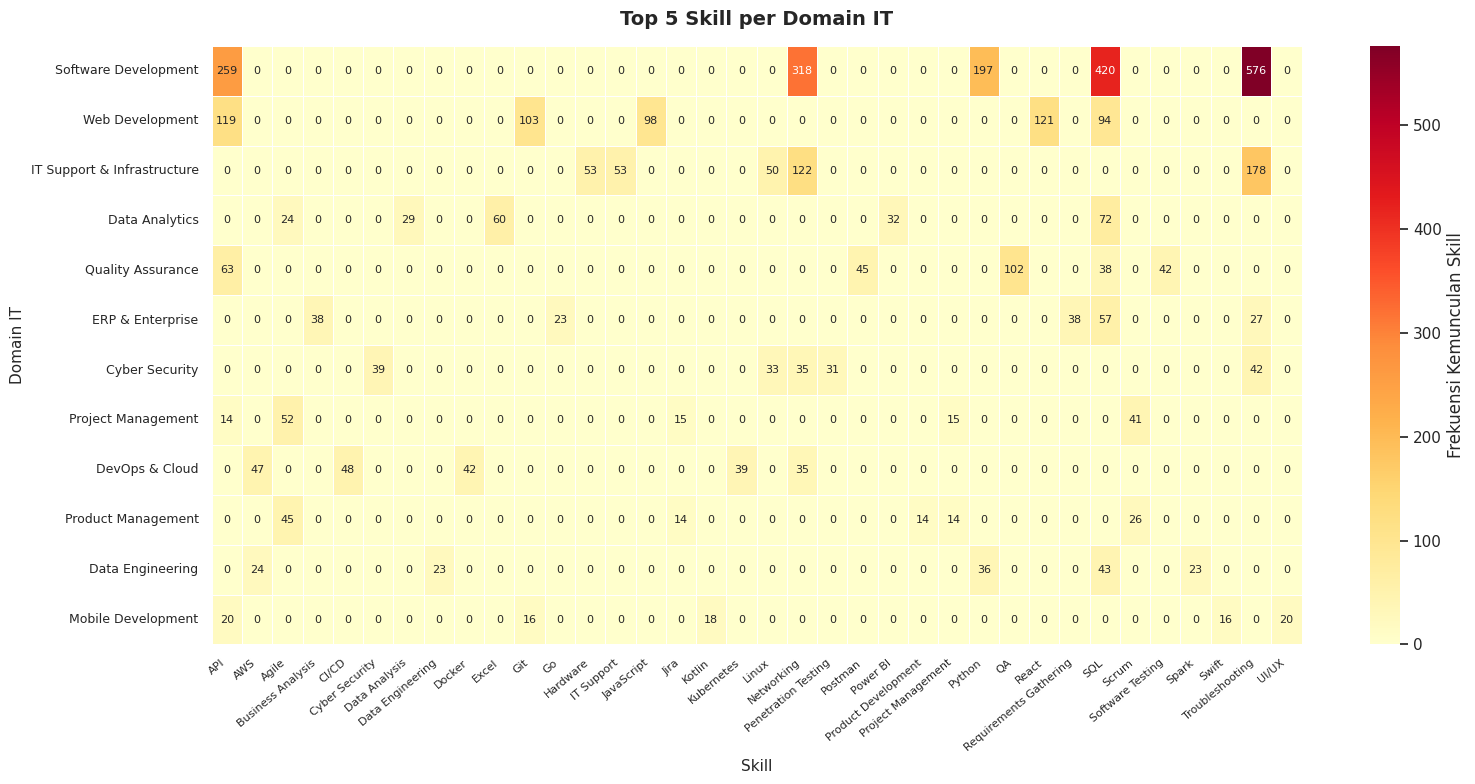

In [14]:
major_domains = df_clean['job_domain'].value_counts()[
    df_clean['job_domain'].value_counts() >= 30].index.tolist()

top_skills_per_domain = {}
for domain in major_domains:
    counter = Counter()
    for skills in df_clean[df_clean['job_domain'] == domain]['required_skills']:
        for s in skills:
            counter[s] += 1
    top_skills_per_domain[domain] = dict(counter.most_common(5))

all_top_skills = sorted(set(s for skills in top_skills_per_domain.values() for s in skills))
heatmap_data = pd.DataFrame(index=major_domains, columns=all_top_skills).fillna(0)
for domain, skills in top_skills_per_domain.items():
    for skill, count in skills.items():
        heatmap_data.loc[domain, skill] = count
heatmap_data = heatmap_data.astype(float)

fig, ax = plt.subplots(figsize=(16, 8))
sns.heatmap(heatmap_data, ax=ax, cmap='YlOrRd', linewidths=0.4, linecolor='white',
            annot=True, fmt='.0f', annot_kws={'size': 8},
            cbar_kws={'label': 'Frekuensi Kemunculan Skill'})
ax.set_title('Top 5 Skill per Domain IT', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Skill', fontsize=11)
ax.set_ylabel('Domain IT', fontsize=11)
ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha='right', fontsize=8)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)
plt.tight_layout()
plt.show()


**Insight:**
- Skill seperti **SQL, Python, Git, dan API** bersifat lintas domain — muncul sebagai skill utama di banyak domain sekaligus, menandakan bahwa ini adalah *foundational skills* yang harus dimiliki hampir semua IT professional.
- **Docker dan CI/CD** sangat dominan di DevOps & Cloud, sesuai praktik industri modern.
- Heatmap ini menjadi referensi langsung untuk fitur **Skill Gap Analysis** di NeoKarir — membandingkan skill yang dimiliki user dengan skill dominan di domain yang dituju.


## 5. Data Dictionary

| Kolom | Tipe Data | Deskripsi |
|-------|-----------|-----------|
| `Job Title` | string | Judul posisi pekerjaan yang diiklankan |
| `Job URL` | string | URL unik lowongan di JobStreet (identifier) |
| `Company` | string | Nama perusahaan yang membuka lowongan |
| `Location` | string | Kota atau wilayah penempatan kerja |
| `Job Description` | string | Deskripsi lengkap pekerjaan dari posting asli |
| `required_skills` | list | Daftar skill yang dibutuhkan (hasil ekstraksi + imputasi) |
| `job_domain` | string | Domain IT hasil mapping dari `Job Title` via keyword matching |
| `skill_count` | integer | Jumlah skill yang dibutuhkan per lowongan (kolom turunan) |


## 6. Kesimpulan

Berdasarkan analisis yang telah dilakukan, berikut jawaban atas pertanyaan bisnis:

1. **Skill yang paling dibutuhkan** adalah Troubleshooting, SQL, API, Python, dan Agile — dengan Python dan SQL menjadi skill lintas domain yang paling universal dan wajib dikuasai.

2. **Domain dengan lowongan terbanyak** adalah Software Development, Web Development, dan IT Support & Infrastructure. UI/UX Design dan Game Development memiliki pasar yang lebih sempit.

3. **Rata-rata skill yang diminta** adalah 4–5 skill per lowongan dengan distribusi right-skewed — beberapa lowongan senior meminta hingga 27 skill sekaligus.

4. **Skill dominan per domain** bervariasi: React/JavaScript untuk Web, Python/TensorFlow untuk Data Science & AI, Docker/Kubernetes untuk DevOps. Namun Git dan SQL bersifat universal di hampir semua domain.

---

### Catatan untuk Tim AI

Dataset `master_job_catalog.csv` yang dihasilkan dari notebook ini adalah **dataset sentral** yang digunakan oleh hampir seluruh fitur NeoKarir. Berikut keterkaitannya:

| Fitur | Kolom yang Digunakan | Catatan |
|-------|----------------------|---------|
| **Job Match Score** | `required_skills`, `job_domain` | Kolom `required_skills` sudah dalam format list Python — langsung bisa dipakai untuk Cosine Similarity / Jaccard Similarity |
| **Skill Gap Analysis** | `required_skills`, `job_domain` | Nama skill sudah distandardisasi (Title Case konsisten) — pastikan nama skill di profil user mengikuti standar yang sama |
| **AI Career Profiling** | `job_domain`, `job_title`, `min_experience`, `min_education` | Dipakai untuk filter dan matching profil user dari hasil survei onboarding |
| **Personalized Career Recommendation** | Semua kolom | Basis utama sistem rekomendasi karier berdasarkan profil user |
| **Market Trend (Prophet/LSTM)** | `required_skills`, `job_domain` | Nama skill di `market_trend_history.csv` mengacu pada nama skill di katalog ini — pastikan konsisten |
| **Roadmap Belajar** | `required_skills` | `target_skills` di `roadmap.json` sudah disesuaikan dengan nama skill di katalog ini |
| **Smart CV Analyzer (BIO Tagging)** | `required_skills` | Nama skill di katalog ini menjadi referensi label `B-SKILL` / `I-SKILL` dalam proses anotasi NER |
| **AI Career Chat Assistant (RAG)** | `job_title`, `job_domain`, `required_skills` | Data dari katalog bisa menjadi bagian dari knowledge base chatbot untuk menjawab pertanyaan terkait syarat loker |

**Hal penting yang perlu diperhatikan tim AI:**
- Kolom `required_skills` berbentuk **string representasi list Python** — gunakan `ast.literal_eval()` saat membacanya, bukan `json.loads()`
- Nama skill sudah **Title Case** dan konsisten — pastikan pipeline NLP tidak mengubah casing skill saat preprocessing
- Kolom `min_experience` menggunakan kategori: `Belum ada pengalaman`, `< 1 Tahun`, `1 - 3 Tahun`, `3 - 5 Tahun`, `> 5 Tahun` — sesuaikan dengan opsi di kuesioner survei onboarding
- Kolom `min_education` menggunakan kategori: `SMA/SMK`, `D3`, `S1/D4`, `S2/S3`, `Bootcamp/Sertifikasi` — sudah sesuai dengan pilihan di survei onboarding
